# YOLOv8 Pet Detection
## Training on Kaggle Dog and Cat Detection Dataset

In [1]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Tuple
import random
from collections import Counter
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [18]:
import xml.etree.ElementTree as ET
from pathlib import Path
import cv2


XML_DIR = Path(r"D:/hse_cv2/annotations/annotations") 
TEST_IMG_DIR = Path("pet_dataset_final/images/test")
TEST_LABEL_DIR = Path("pet_dataset_final/labels/test")
TEST_LABEL_DIR.mkdir(parents=True, exist_ok=True)

CLASS_MAP = {
    "cat": 0,
    "dog": 1,
    "Cats": 0,  
    "Dogs": 1,
}

def voc_xml_to_yolo_txt(xml_path: Path, img_dir: Path, out_dir: Path):
    tree = ET.parse(str(xml_path))
    root = tree.getroot()

    filename = root.find("filename").text
    img_path = img_dir / filename
    if not img_path.exists():
        print(f"[WARN] image not found for {xml_path.name}: {img_path}")
        return

    img = cv2.imread(str(img_path))
    if img is None:
        print(f"[WARN] cannot read image: {img_path}")
        return
    h, w = img.shape[:2]

    lines = []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        if name not in CLASS_MAP:
            print(f"[WARN] unknown class '{name}' in {xml_path.name}, skip")
            continue
        cls_id = CLASS_MAP[name]

        bnd = obj.find("bndbox")
        xmin = float(bnd.find("xmin").text)
        ymin = float(bnd.find("ymin").text)
        xmax = float(bnd.find("xmax").text)
        ymax = float(bnd.find("ymax").text)

        # VOC -> YOLO
        x_c = (xmin + xmax) / 2.0 / w
        y_c = (ymin + ymax) / 2.0 / h
        bw = (xmax - xmin) / w
        bh = (ymax - ymin) / h

        # в пределах [0,1]
        x_c = max(0, min(1, x_c))
        y_c = max(0, min(1, y_c))
        bw = max(0, min(1, bw))
        bh = max(0, min(1, bh))

        lines.append(f"{cls_id} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}")

    if not lines:
        print(f"[INFO] no objects in {xml_path.name}")
        return

    out_path = out_dir / (img_path.stem + ".txt")
    out_path.write_text("\n".join(lines), encoding="utf-8")
    print(f"[OK] {xml_path.name} -> {out_path.name}")

xml_files = sorted(XML_DIR.glob("Cats_Test*.xml"))
print("Total XML files:", len(xml_files))

for xp in xml_files:
    voc_xml_to_yolo_txt(xp, TEST_IMG_DIR, TEST_LABEL_DIR)

print("Done, labels saved to:", TEST_LABEL_DIR)


Total XML files: 3686
[WARN] image not found for Cats_Test0.xml: pet_dataset_final\images\test\Cats_Test0.png
[OK] Cats_Test1.xml -> Cats_Test1.txt
[OK] Cats_Test10.xml -> Cats_Test10.txt
[WARN] image not found for Cats_Test100.xml: pet_dataset_final\images\test\Cats_Test100.png
[WARN] image not found for Cats_Test1000.xml: pet_dataset_final\images\test\Cats_Test1000.png
[WARN] image not found for Cats_Test1001.xml: pet_dataset_final\images\test\Cats_Test1001.png
[OK] Cats_Test1002.xml -> Cats_Test1002.txt
[WARN] image not found for Cats_Test1003.xml: pet_dataset_final\images\test\Cats_Test1003.png
[OK] Cats_Test1004.xml -> Cats_Test1004.txt
[WARN] image not found for Cats_Test1005.xml: pet_dataset_final\images\test\Cats_Test1005.png
[WARN] image not found for Cats_Test1006.xml: pet_dataset_final\images\test\Cats_Test1006.png
[WARN] image not found for Cats_Test1007.xml: pet_dataset_final\images\test\Cats_Test1007.png
[WARN] image not found for Cats_Test1008.xml: pet_dataset_final\imag

## Step 10: Inference

In [19]:
class PetDetectorAnalyzer:
    def __init__(self, model_path: str):
        self.model = YOLO(model_path)
        self.classes = ['cat', 'dog']
        np.random.seed(42)
        self.colors = {
            0: (255, 0, 0),      # Blue for cat
            1: (0, 0, 255)       # Red for dog
        }
        print(f'Model loaded: {model_path}')
    
    def detect(self, image_path: str, conf: float = 0.5):
        """Инференс на одном изображении"""
        img = cv2.imread(str(image_path))
        if img is None:
            return None, []
        results = self.model.predict(img, conf=conf, verbose=False)
        detections = []
        for result in results:
            for box in result.boxes:
                detections.append({
                    'class_id': int(box.cls[0]),
                    'class_name': self.classes[int(box.cls[0])],
                    'conf': float(box.conf[0]),
                    'bbox': [float(x) for x in box.xyxy[0]]
                })
        return img, detections
    
    def visualize(self, img, detections, show_labels=True):
        """Визуализирует предсказания на изображении"""
        img_vis = img.copy()
        for det in detections:
            x1, y1, x2, y2 = map(int, det['bbox'])
            color = self.colors[det['class_id']]
            cv2.rectangle(img_vis, (x1, y1), (x2, y2), color, 3)
            if show_labels:
                label = f"{det['class_name']} {det['conf']:.2f}"
                (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(img_vis, (x1, y1 - 25), (x1 + w, y1), color, -1)
                cv2.putText(img_vis, label, (x1, y1 - 7),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        return img_vis
    
    def load_ground_truth(self, label_path: str):
        """Загружает GT боксы из YOLO-формата .txt файла"""
        if not Path(label_path).exists():
            return []
        
        gt_boxes = []
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])
                    gt_boxes.append({
                        'class_id': class_id,
                        'class_name': self.classes[class_id],
                        'bbox_norm': (x_center, y_center, width, height)
                    })
        return gt_boxes
    
    def convert_norm_to_pixel(self, img, bbox_norm):
        h, w = img.shape[:2]
        x_center_norm, y_center_norm, width_norm, height_norm = bbox_norm
        
        x_center_px = x_center_norm * w
        y_center_px = y_center_norm * h
        width_px = width_norm * w
        height_px = height_norm * h
        
        x1 = int(x_center_px - width_px / 2)
        y1 = int(y_center_px - height_px / 2)
        x2 = int(x_center_px + width_px / 2)
        y2 = int(y_center_px + height_px / 2)
        
        return [x1, y1, x2, y2]

    
    def compute_iou(self, box1, box2):
        """Вычисляет IoU (Intersection over Union) между двумя боксами"""
        x1_min, y1_min, x1_max, y1_max = box1
        x2_min, y2_min, x2_max, y2_max = box2
        
        inter_xmin = max(x1_min, x2_min)
        inter_ymin = max(y1_min, y2_min)
        inter_xmax = min(x1_max, x2_max)
        inter_ymax = min(y1_max, y2_max)
        
        if inter_xmax < inter_xmin or inter_ymax < inter_ymin:
            return 0.0
        
        inter_area = (inter_xmax - inter_xmin) * (inter_ymax - inter_ymin)
        box1_area = (x1_max - x1_min) * (y1_max - y1_min)
        box2_area = (x2_max - x2_min) * (y2_max - y2_min)
        
        union_area = box1_area + box2_area - inter_area
        
        return inter_area / union_area if union_area > 0 else 0.0
    
    def match_predictions_to_gt(self, predictions, ground_truths, iou_threshold=0.5):
        """
        Сопоставляет предсказания с GT боксами.
        Возвращает: TP, FP, FN
        """
        tp, fp, fn = 0, 0, 0
        matched_gt = set()
        
        sorted_preds = sorted(predictions, key=lambda x: x['conf'], reverse=True)
        
        for pred in sorted_preds:
            best_iou = 0
            best_gt_idx = -1
            
            for gt_idx, gt in enumerate(ground_truths):
                if gt_idx in matched_gt:
                    continue  
                
                if pred['class_id'] != gt['class_id']:
                    continue  
                
                iou = self.compute_iou(pred['bbox'], gt['bbox_pixel'])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx
            
            if best_iou >= iou_threshold and best_gt_idx >= 0:
                tp += 1
                matched_gt.add(best_gt_idx)
            else:
                fp += 1
        
        fn = len(ground_truths) - len(matched_gt)
        
        return tp, fp, fn


In [20]:
MODEL_PATH = 'pet_model_final.pt'
TEST_DIR = Path('pet_dataset_final/images/test')
LABELS_DIR = Path('pet_dataset_final/labels/test')

analyzer = PetDetectorAnalyzer(MODEL_PATH)

test_images = sorted(list(TEST_DIR.glob('*.jpg')) + list(TEST_DIR.glob('*.png')))
print(f'Found {len(test_images)} test images')

CONF_THRESHOLD = 0.3
IOU_THRESHOLD = 0.5
N_SAMPLES = 100

random.seed(42)
sample_images = random.sample(test_images, min(N_SAMPLES, len(test_images)))

total_tp = 0
total_fp = 0
total_fn = 0
all_results = []
metrics_per_image = []

for img_path in sample_images:
    img, predictions = analyzer.detect(str(img_path), conf=CONF_THRESHOLD)
    
    if img is None:
        continue
    
    label_path = LABELS_DIR / (img_path.stem + '.txt')
    ground_truths = analyzer.load_ground_truth(str(label_path))
    
    for gt in ground_truths:
        gt['bbox_pixel'] = analyzer.convert_norm_to_pixel(img, gt['bbox_norm'])
    
    tp, fp, fn = analyzer.match_predictions_to_gt(
        predictions, 
        ground_truths, 
        iou_threshold=IOU_THRESHOLD
    )
    
    total_tp += tp
    total_fp += fp
    total_fn += fn
    
    metrics_per_image.append({
        'path': str(img_path),
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'n_predictions': len(predictions),
        'n_ground_truth': len(ground_truths),
        'image': img,
        'predictions': predictions,
        'ground_truths': ground_truths
    })
    
    all_results.append({
        'path': str(img_path),
        'image': img,
        'detections': predictions,
        'n_detections': len(predictions)
    })


Model loaded: pet_model_final.pt
Found 554 test images


In [21]:
print(f'Total TP (True Positives):   {total_tp}')
print(f'Total FP (False Positives):  {total_fp}')
print(f'Total FN (False Negatives):  {total_fn}')

precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f'Precision (TP/(TP+FP)): {precision:.4f}')
print(f'Recall (TP/(TP+FN)):    {recall:.4f}')
print(f'F1-Score:               {f1:.4f}')

print(f'\nProcessed {len(metrics_per_image)} images')


Total TP (True Positives):   94
Total FP (False Positives):  15
Total FN (False Negatives):  6
Precision (TP/(TP+FP)): 0.8624
Recall (TP/(TP+FN)):    0.9400
F1-Score:               0.8995

Processed 100 images



True Positives (правильные детекции): 85 изображений


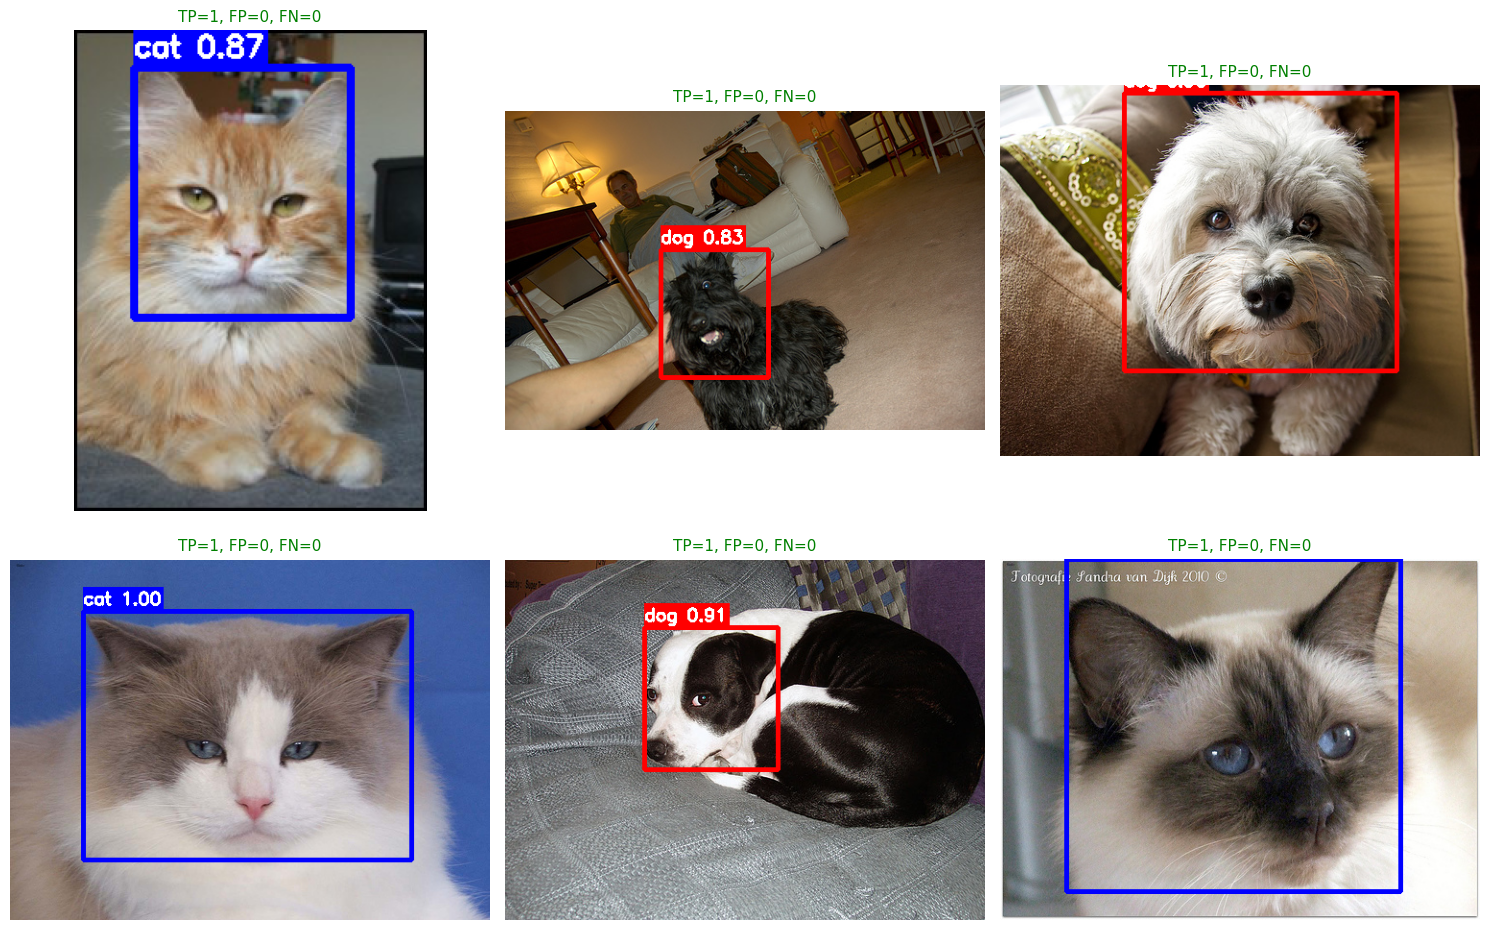

False Positives (ложные детекции): 14 изображений


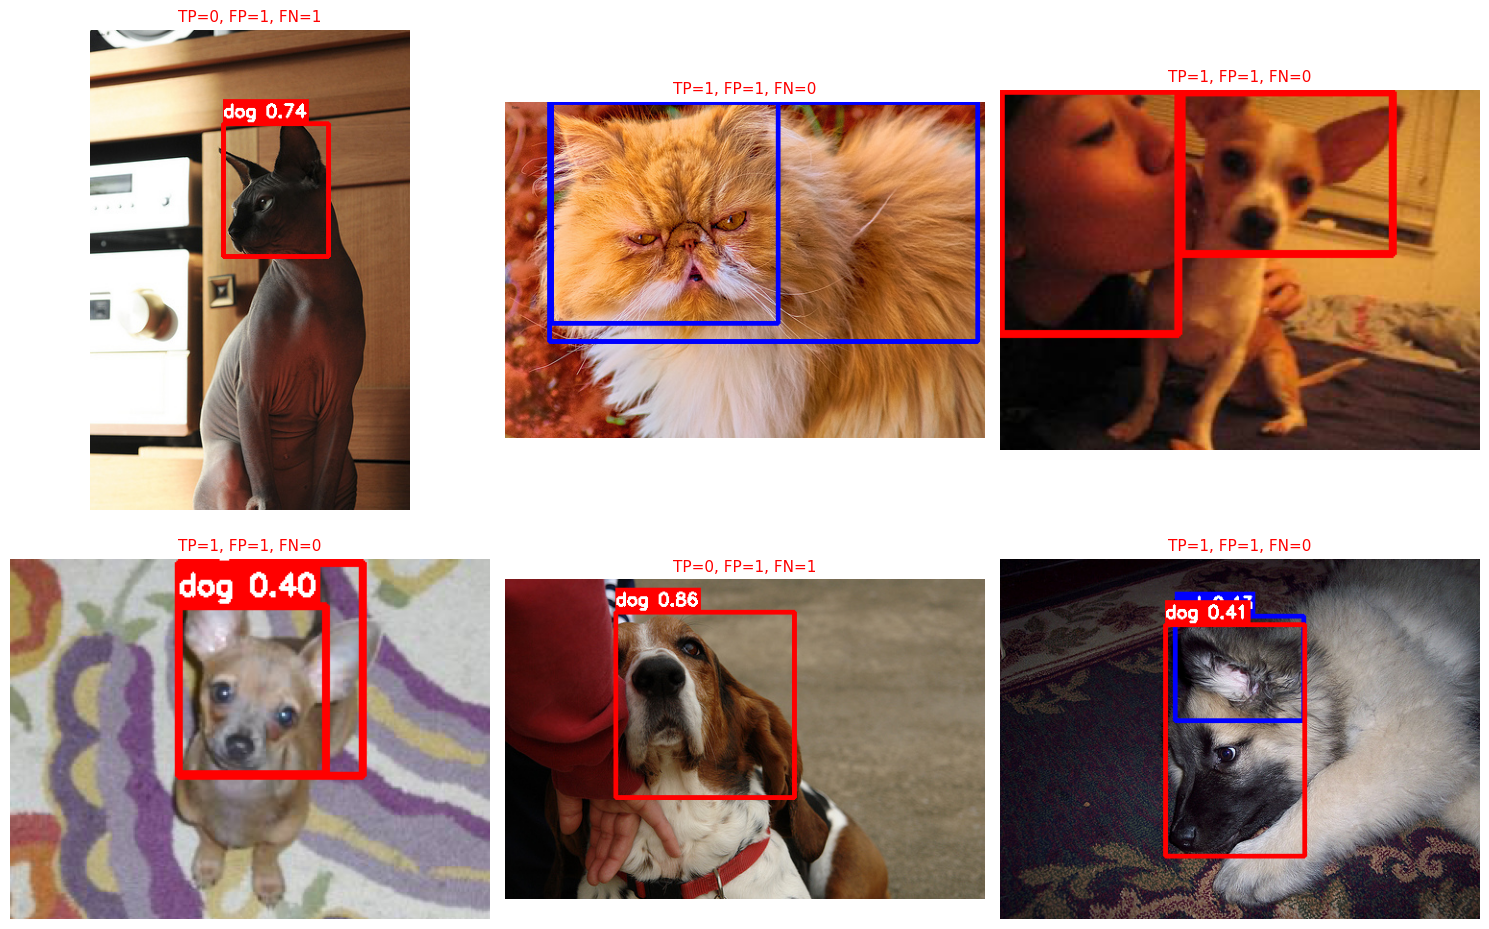

False Negatives (пропущенные объекты): 6 изображений


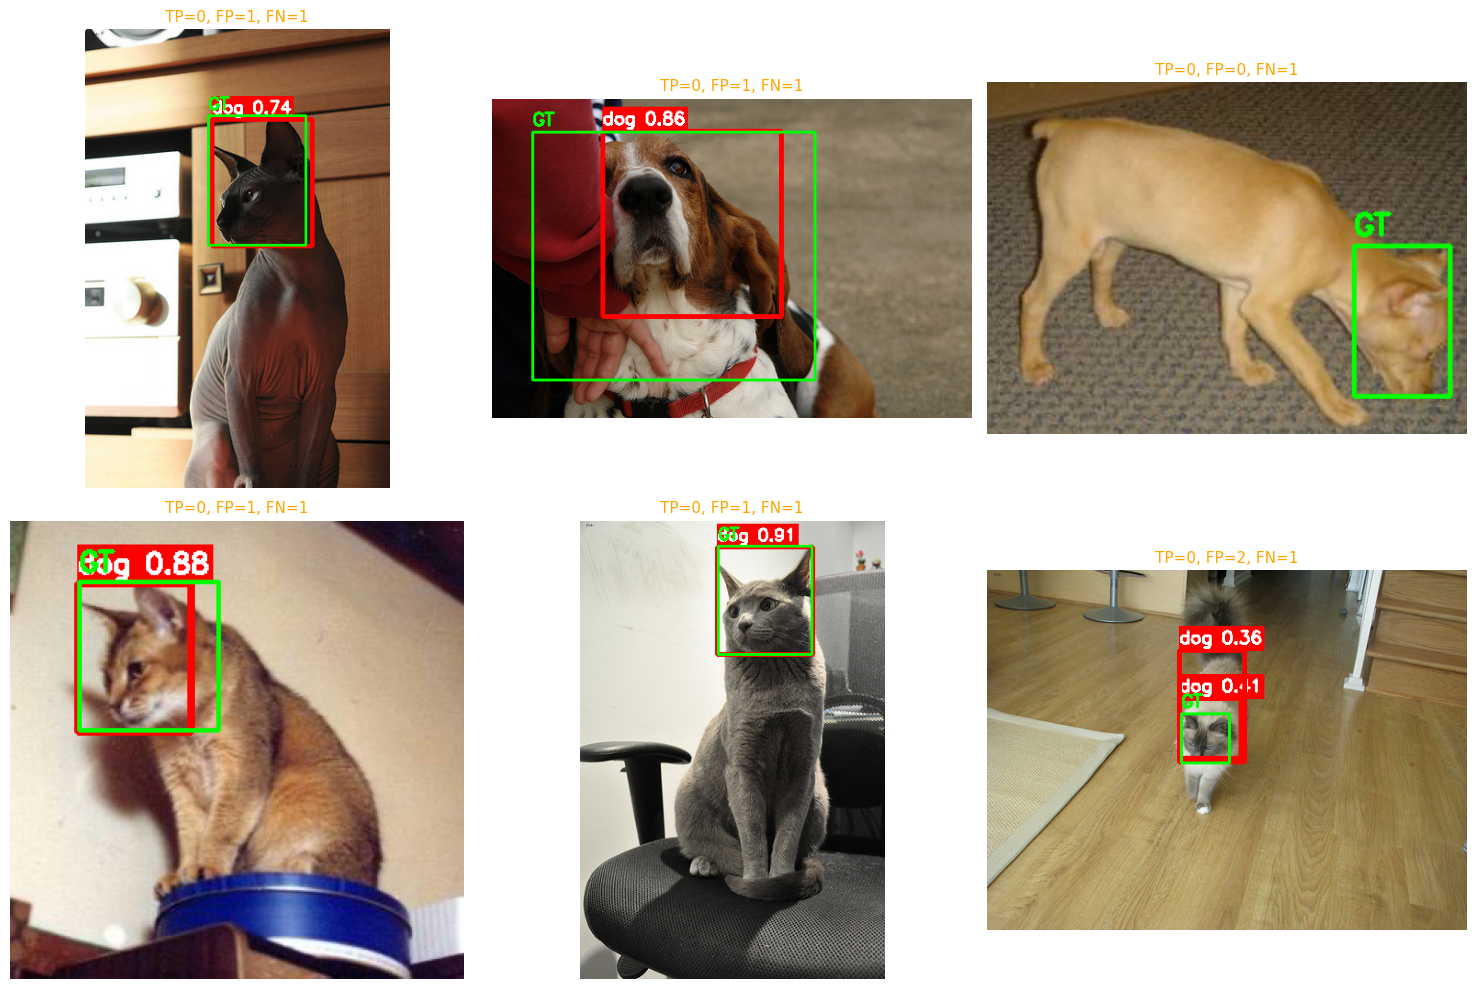

In [22]:
# TP 
tp_examples = [m for m in metrics_per_image if m['tp'] > 0 and m['fp'] == 0]
print(f'\nTrue Positives (правильные детекции): {len(tp_examples)} изображений')

if tp_examples:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, result in enumerate(tp_examples[:6]):
        img_vis = analyzer.visualize(result['image'], result['predictions'])
        img_rgb = cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"TP={result['tp']}, FP={result['fp']}, FN={result['fn']}", 
                         fontsize=11, color='green')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('true_positives.jpg', dpi=150, bbox_inches='tight')
    plt.show()

# FP 
fp_examples = [m for m in metrics_per_image if m['fp'] > 0]
print(f'False Positives (ложные детекции): {len(fp_examples)} изображений')

if fp_examples:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, result in enumerate(fp_examples[:6]):
        img_vis = analyzer.visualize(result['image'], result['predictions'])
        img_rgb = cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"TP={result['tp']}, FP={result['fp']}, FN={result['fn']}", 
                         fontsize=11, color='red')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('false_positives.jpg', dpi=150, bbox_inches='tight')
    plt.show()

# FN 
fn_examples = [m for m in metrics_per_image if m['fn'] > 0]
print(f'False Negatives (пропущенные объекты): {len(fn_examples)} изображений')

if fn_examples:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, result in enumerate(fn_examples[:6]):
        img_vis = analyzer.visualize(result['image'], result['predictions'])
        img_rgb = cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB)
        
        for gt in result['ground_truths']:
            x1, y1, x2, y2 = map(int, gt['bbox_pixel'])
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img_rgb, 'GT', (x1, y1 - 7),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"TP={result['tp']}, FP={result['fp']}, FN={result['fn']}", 
                         fontsize=11, color='orange')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('false_negatives.jpg', dpi=150, bbox_inches='tight')
    plt.show()

Анализ причин ошибок  

1. Масштаб объекта на изображении
Малые объекты труднее распознавать 
Решение: увеличить разрешение обучения (imgsz=640), добавить аугментации масштаба

2. Освещение
Плохое освещение, тени, засветки снижают качество
Решение: аугментации яркости/контраста, больше примеров с разным освещением

3. Сложный фон
Объект сливается с фоном по цвету/текстуре
Решение: больше разнообразных фонов в обучающей выборке

4. Мало данных
Недостаточно примеров необычных поз, ракурсов, пород
Решение: увеличить датасет, добавить синтетические данные

5. Архитектурные ограничения
YOLOv8n - самая легкая версия, trade-off скорость/точность
Решение: использовать YOLOv8m/l/x для более высокой точности

6. Параметры обучения
Малое количество эпох (5), низкое разрешение (320)
Решение: epochs=50-100, imgsz=640, больше аугментаций

## Шаг 13:  Confidence distribution visualization

C:\Users\a.moiseeva\AppData\Local\Temp\ipykernel_84716\955649867.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=labels)


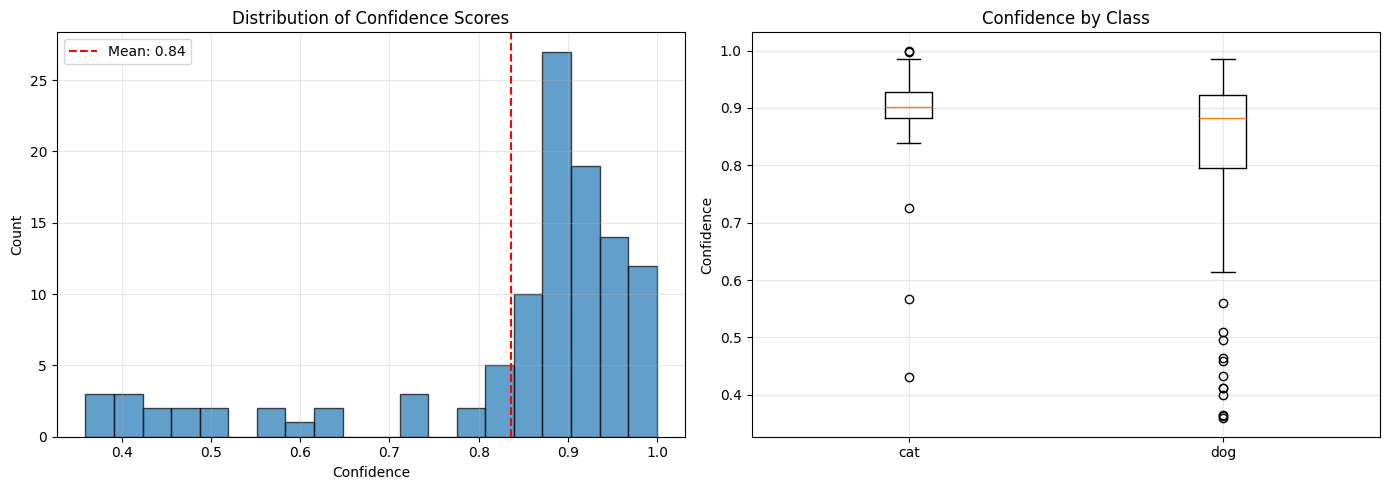

Cat mean confidence: 0.888
Dog mean confidence: 0.809


In [24]:
all_confidences = []
cat_conf = []
dog_conf = []

for m in metrics_per_image:
    for d in m['predictions']:
        all_confidences.append(d['conf'])
        if d['class_id'] == 0:      # cat
            cat_conf.append(d['conf'])
        elif d['class_id'] == 1:    # dog
            dog_conf.append(d['conf'])

if all_confidences:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Гистограмма всех confidence
    axes[0].hist(all_confidences, bins=20, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Confidence')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of Confidence Scores')
    axes[0].axvline(np.mean(all_confidences), color='red',
                    linestyle='--', label=f'Mean: {np.mean(all_confidences):.2f}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Boxplot по классам (если есть данные)
    data = []
    labels = []
    if cat_conf:
        data.append(cat_conf)
        labels.append('cat')
    if dog_conf:
        data.append(dog_conf)
        labels.append('dog')
    
    if data:
        axes[1].boxplot(data, labels=labels)
        axes[1].set_ylabel('Confidence')
        axes[1].set_title('Confidence by Class')
        axes[1].grid(alpha=0.3)
    else:
        axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig('confidence_distribution.jpg', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Cat mean confidence: {np.mean(cat_conf):.3f}" if cat_conf else "No cats detected")
    print(f"Dog mean confidence: {np.mean(dog_conf):.3f}" if dog_conf else "No dogs detected")
